In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import librosa as lb
import soundfile as sf
import os
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from smart_stethoscope.ml_logic import data_loading

In [4]:
data_loading.load_data()


Extracting respiratory cycles from audio...

✅ Processed 6898 audio files

Load data from raw data folder...


,start,end,crackles,wheezes,filename,chest_location,cycle_filename,disease,age,sex,adult_bmi,child_weight,child_height
0,0.022,0.364,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_0,URTI,4.0,M,NaN,33.0,110.0
1,0.364,2.436,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_1,URTI,4.0,M,NaN,33.0,110.0
2,2.436,4.636,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_2,URTI,4.0,M,NaN,33.0,110.0
3,4.636,6.793,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_3,URTI,4.0,M,NaN,33.0,110.0
4,6.793,8.750,0,0,148_1b1_Al_sc_Meditron,Al,148_1b1_Al_sc_Meditron_4,URTI,4.0,M,NaN,33.0,110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6893,16.946,19.156,1,0,130_2b3_Al_mc_AKGC417L,Al,130_2b3_Al_mc_AKGC417L_8,COPD,85.0,F,17.10,NaN,NaN
6894,0.022,3.450,0,0,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_0,Bronchiectasis,56.0,M,28.58,NaN,NaN
6895,3.450,10.507,0,1,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_1,Bronchiectasis,56.0,M,28.58,NaN,NaN
6896,10.507,17.336,0,1,116_1b2_Pl_sc_Meditron,Pl,116_1b2_Pl_sc_Meditron_2,Bronchiectasis,56.0,M,28.58,NaN,NaN


In [5]:
audio_file_path = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.wav'
annotation_file_path = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/101_1b1_Al_sc_Meditron.txt'
annotations=pd.read_csv(annotation_file_path,sep='\t',names=['start','end','crackles','weezels'])
audio, sr = lb.load(audio_file_path, sr=None)
from smart_stethoscope.interface import main
breathing_cycles_features = main.predict(audio, sr, annotations)


In [6]:
breathing_cycles_features.shape

(12, 13, 259)

In [18]:
test = data_loading.load_tabular_data()
test.head()

,start,end,crackles,wheezes,filename,pid,chest_location,disease,age,sex,adult_bmi,child_weight,child_height
0,0.022,0.364,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
1,0.364,2.436,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
2,2.436,4.636,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
3,4.636,6.793,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0
4,6.793,8.750,0,0,148_1b1_Al_sc_Meditron,148,Al,URTI,4.0,M,NaN,33.0,110.0


### Load Demographic and Diagnosis Data

In [4]:
path_demographic_data = '../raw_data/demographic_info.txt'
column_names = ['pid', 'age', 'sex', 'adult_BMI', 'child_weight', 'child_height']
demographic_data = pd.read_csv(path_demographic_data, names=column_names, sep=' ', header=None)

demographic_data.head()

,pid,age,sex,adult_BMI,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [6]:
demographic_data.isnull().sum()

pid              0
age              1
sex              1
adult_BMI       51
child_weight    82
child_height    84
dtype: int64

In [5]:
demographic_data.dtypes

pid               int64
age             float64
sex              object
adult_BMI       float64
child_weight    float64
child_height    float64
dtype: object

In [19]:
path_diagnosis_data = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv'
col_names_diagnosis = ['pid', 'diagnosis']
diagnosis_data = pd.read_csv(path_diagnosis_data, header=None, names=col_names_diagnosis)

diagnosis_data.head()

,pid,diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [8]:
diagnosis_data.isnull().sum()

pid          0
diagnosis    0
dtype: int64

In [9]:
diagnosis_data.dtypes

pid           int64
diagnosis    object
dtype: object

### Load Audio Annotations

In [45]:
annotation_folder = '../raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/'

In [46]:
files = [file.split('.')[0] for file in os.listdir(annotation_folder) if file.endswith('.txt') ]
files[0]

'148_1b1_Al_sc_Meditron'

In [47]:
def getFilenameInfo(file):
    return file.split('_')

In [48]:
files_data=[]
for file in files:
    data=pd.read_csv(annotation_folder + file + '.txt',sep='\t',names=['start','end','crackles','weezels'])
    name_data=getFilenameInfo(file)
    data['pid']=name_data[0]
    data['chest_location']=name_data[2]
    data['mode']=name_data[-2]
    data['filename']=file
    files_data.append(data)
files_df=pd.concat(files_data)
files_df.reset_index()
files_df.head()

,start,end,crackles,weezels,pid,chest_location,mode,filename
0,0.022,0.364,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
1,0.364,2.436,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
2,2.436,4.636,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
3,4.636,6.793,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
4,6.793,8.750,0,0,148,Al,sc,148_1b1_Al_sc_Meditron


In [14]:
diagnosis_data.pid = diagnosis_data.pid.astype('int32')
files_df.pid = files_df.pid.astype('int32')
demographic_data.pid = demographic_data.pid.astype('int32')

In [15]:
data=pd.merge(files_df,diagnosis_data,on='pid')
data.head()

,start,end,crackles,weezels,pid,chest_location,mode,filename,diagnosis
0,0.022,0.364,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
1,0.364,2.436,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
2,2.436,4.636,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
3,4.636,6.793,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI
4,6.793,8.750,0,0,148,Al,sc,148_1b1_Al_sc_Meditron,URTI


In [ ]:
os.makedirs('../raw_data/csv_data')
data.to_csv('../raw_data/csv_data/data.csv',index=False)

In [19]:
data.value_counts('diagnosis')

diagnosis
COPD              5746
Healthy            322
Pneumonia          285
URTI               243
Bronchiolitis      160
Bronchiectasis     104
LRTI                32
Asthma               6
Name: count, dtype: int64

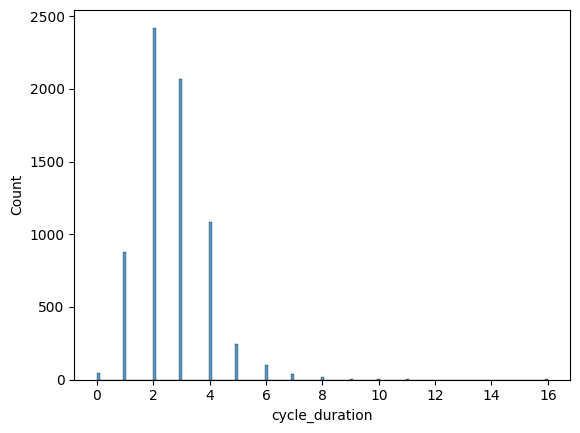

In [32]:
data['cycle_duration'] = data['end']-data['start']
sns.histplot(data=data, x=round(data['cycle_duration'],0));

### Preprocessing audio data

In [ ]:
preproc_audio_path = '../raw_data/preprocessed_audio_files/'
os.makedirs(preproc_audio_path)

In [ ]:
def getPureSample(raw_data,start,end,sr=22050):
    '''
    Takes a numpy array and spilts its using start and end args

    raw_data=numpy array of audio sample
    start=time
    end=time
    sr=sampling_rate
    mode=mono/stereo

    '''
    max_ind = len(raw_data)
    start_ind = min(int(start * sr), max_ind)
    end_ind = min(int(end * sr), max_ind)
    return raw_data[start_ind: end_ind]

In [ ]:

i,c=0,0
for index,row in data.iterrows():
    maxLen=6
    start=row['start']
    end=row['end']
    filename=row['filename']

    #If len > maxLen , change it to maxLen
    if end-start>maxLen:
        end=start+maxLen

    audio_file_loc=annotation_folder + filename + '.wav'

    if index > 0:
        #check if more cycles exits for same patient if so then add i to change filename
        if data.iloc[index-1]['filename']==filename:
            i+=1
        else:
            i=0
    filename= filename + '_' + str(i) + '.wav'

    save_path=preproc_audio_path + filename
    c+=1

    audioArr,sampleRate=lb.load(audio_file_loc)
    pureSample=getPureSample(audioArr,start,end,sampleRate)

    #pad audio if pureSample len < max_len
    reqLen = 6*sampleRate
    padded_data = lb.util.pad_center(data=pureSample, size=reqLen)

    sf.write(file=save_path,data=padded_data,samplerate=sampleRate)
print('Total Files Processed: ',c)

Total Files Processed:  6898


### Feature Extraction Experimenting

In [1]:
import IPython
IPython.display.Audio("../raw_data/preprocessed_audio_files/130_3p2_Tc_mc_AKGC417L_1.wav")

In [ ]:
import librosa.display as lbd
soundArr,sample_rate=lb.load("../raw_data/preprocessed_audio_files/130_3p2_Tc_mc_AKGC417L_1.wav")
mfcc=lb.feature.mfcc(y=soundArr,sr=sample_rate)
mel_spec = lb.feature.melspectrogram(y=soundArr, sr=sample_rate)
mfcc_val=np.array(mfcc)
mfcc_val

array([[-821.7861, -821.7861, -821.7861, ..., -821.7861, -821.7861,
        -821.7861],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       ...,
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ]], shape=(20, 259), dtype=float32)

[Text(0.5, 1.0, 'MFCC')]

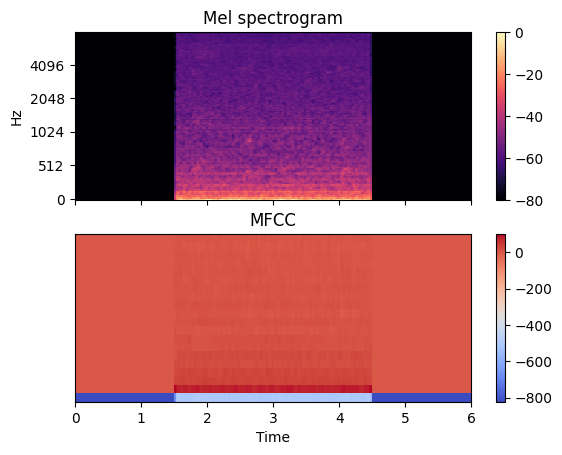

In [89]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, sharex=True)
img = lb.display.specshow(lb.power_to_db(mel_spec, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = lb.display.specshow(mfcc, x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')


### Check if any recording is not mono

In [93]:
import soundfile as sf

folder = annotation_folder

for f in os.listdir(folder):
    if f.endswith(".wav"):
        data, sr = sf.read(os.path.join(folder, f))
        if len(data.shape) >1:
            print(f, data.shape)

In [121]:
test = files_df[['pid', 'filename', 'mode']]
test = test[test['mode'] == 'mc']
test = test.drop_duplicates()
test['pid'].value_counts()
test[test['pid']==198]

,pid,filename,mode
0,198,198_6p1_Ll_mc_AKGC417L,mc
0,198,198_1b5_Ll_mc_AKGC417L,mc
0,198,198_1b5_Ar_mc_AKGC417L,mc
0,198,198_6p1_Ar_mc_AKGC417L,mc
0,198,198_6p1_Pr_mc_AKGC417L,mc
0,198,198_1b5_Pr_mc_AKGC417L,mc
0,198,198_6p1_Lr_mc_AKGC417L,mc
0,198,198_1b5_Lr_mc_AKGC417L,mc
0,198,198_1b5_Al_mc_AKGC417L,mc
0,198,198_6p1_Al_mc_AKGC417L,mc


In [65]:
import os
from smart_stethoscope.params import *
#test locally - PoC
# where it's running
current_dir = os.getcwd()
print(f"you are in: {current_dir}")

# folder:
audio_folder = RAW_AUDIO_PATH

if os.path.exists(audio_folder):
    files = [f for f in os.listdir(audio_folder) if f.endswith('.wav')]
    print(f"{len(files)} files .wav")
else:
    print("not found")

you are in: /Users/miameyer/code/mi-mi-mia/smart-stethoscope/notebooks
920 files .wav


In [ ]:
audios = []
audio_folder = RAW_AUDIO_PATH
for file in files:
    path = os.path.join(audio_folder, file)
    y, sr = lb.load(path, sr=12000)
    audios.append(y)

In [ ]:
import plotly.express as px
sr = 12000
lengths_sec = [len(x) / sr for x in audios]

# Create the histogram
fig = px.histogram(
    x=lengths_sec,
    nbins=50,
    labels={'x': 'Duration (seconds)', 'y': 'Count'},
    title="Audio Length Distribution",
    template="plotly_white"
)

# Optional: Add clear hover labels and update layout
fig.update_layout(
    xaxis_title="Duration (seconds)",
    yaxis_title="Count",
    bargap=0.1 # Adds a small gap between bins for better visibility
)

fig.show()

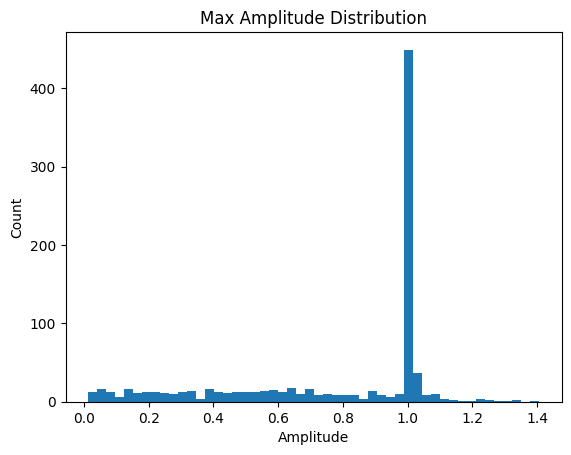

In [35]:
max_amplitudes = [np.max(np.abs(x)) for x in audios]

plt.hist(max_amplitudes, bins=50)
plt.title("Max Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.show()

In [36]:
audio_df = pd.DataFrame(lengths_sec, columns=['length'])
audio_df['filename'] = files
audio_df['max_amplitude'] = max_amplitudes

In [28]:
audio_df[audio_df['length'] > 70]

,length,filename
7,82.50,218_1b1_Lr_sc_Meditron.wav
159,75.25,110_1p1_Pr_sc_Meditron.wav
188,71.05,218_1b1_Al_sc_Meditron.wav
224,71.45,110_1b1_Pr_sc_Meditron.wav
520,86.20,120_1b1_Lr_sc_Meditron.wav
634,71.05,218_1b1_Ar_sc_Meditron.wav
650,73.35,222_1b1_Pr_sc_Meditron.wav
714,74.45,222_1b1_Ar_sc_Meditron.wav


In [31]:
import IPython
path = os.path.join(audio_folder, "218_1b1_Al_sc_Meditron.wav")
IPython.display.Audio(path)

In [32]:
diagnosis_data[diagnosis_data['pid'] == 218]

,pid,diagnosis
117,218,COPD


In [38]:
audio_df[audio_df['max_amplitude'] > 1.2]

,length,filename,max_amplitude
7,82.500000,218_1b1_Lr_sc_Meditron.wav,1.406261
15,67.850000,112_1b1_Ar_sc_Meditron.wav,1.278714
159,75.250000,110_1p1_Pr_sc_Meditron.wav,1.301203
205,20.000083,158_2p2_Ar_mc_AKGC417L.wav,1.255281
252,68.950000,218_1b1_Pl_sc_Meditron.wav,1.211222
307,20.000083,172_1b5_Tc_mc_AKGC417L.wav,1.225614
414,65.050000,157_1b1_Ar_sc_Meditron.wav,1.331274
677,20.000083,172_1b4_Tc_mc_AKGC417L.wav,1.350059
696,68.950000,218_1b1_Pr_sc_Meditron.wav,1.232576
841,20.000083,172_1b4_Al_mc_AKGC417L.wav,1.260476


In [62]:
import IPython
path = os.path.join(audio_folder, "218_1b1_Lr_sc_Meditron.wav")
IPython.display.Audio(path)

In [44]:
diagnosis_data[diagnosis_data['pid'] == 172]

,pid,diagnosis
71,172,COPD


In [50]:
files_df.head()

,start,end,crackles,weezels,pid,chest_location,mode,filename
0,0.022,0.364,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
1,0.364,2.436,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
2,2.436,4.636,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
3,4.636,6.793,0,0,148,Al,sc,148_1b1_Al_sc_Meditron
4,6.793,8.750,0,0,148,Al,sc,148_1b1_Al_sc_Meditron


In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Prepare the data - Sorting is crucial for "continuity" math
df = files_df.sort_values(['filename', 'start'])

# --- ANALYSIS 1: First Cycle Start Times ---
first_cycles = df.groupby('filename')['start'].min().reset_index()

fig1 = px.histogram(
    first_cycles,
    x="start",
    nbins=30,
    title="Distribution of First Breathing Cycle Start Times",
    labels={'start': 'Start Time (seconds)'},
    template="plotly_white"
)
fig1.update_traces(marker_line_width=1, marker_line_color="white")
fig1.show()

# --- ANALYSIS 2: Continuity (Gaps between cycles) ---
# Calculate the previous end time within the same audio file
df['prev_end'] = df.groupby('filename')['end'].shift(1)
df['gap'] = df['start'] - df['prev_end']

# Drop NaN values (the very first cycle of every file has no 'previous' cycle)
gaps = df.dropna(subset=['gap'])

fig2 = px.histogram(
    gaps,
    x="gap",
    nbins=50,
    title="Continuity Analysis: Gaps Between Breathing Cycles",
    labels={'gap': 'Gap Size (seconds) [Start(n) - End(n-1)]'},
    template="plotly_white",
    color_discrete_sequence=['indianred']
)

# Add a vertical line at 0 to show the "Perfect Continuity" threshold
fig2.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Perfectly Continuous")
fig2.show()

In [60]:
files_df[files_df['end']> 80]

,start,end,crackles,weezels,pid,chest_location,mode,filename
18,78.827,82.500,0,0,218,Lr,sc,218_1b1_Lr_sc_Meditron
30,77.191,80.527,0,0,120,Lr,sc,120_1b1_Lr_sc_Meditron
31,80.527,84.365,0,0,120,Lr,sc,120_1b1_Lr_sc_Meditron
32,84.365,86.200,0,0,120,Lr,sc,120_1b1_Lr_sc_Meditron


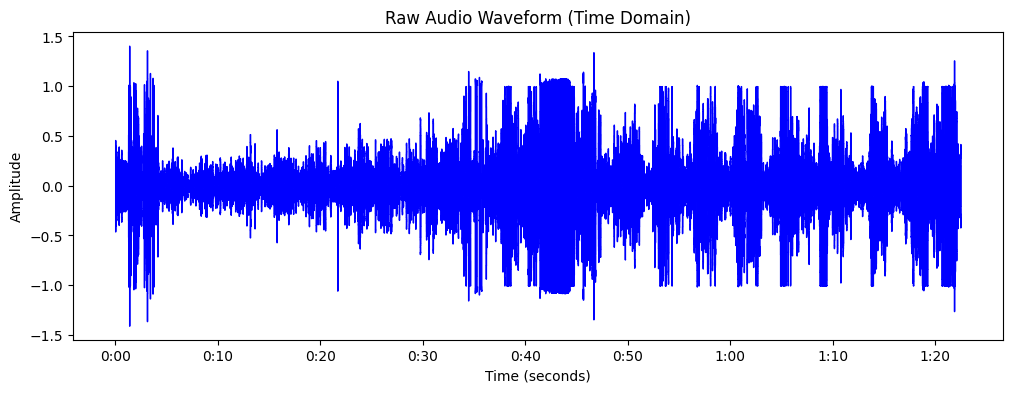

In [91]:
path = os.path.join(audio_folder, "218_1b1_Lr_sc_Meditron.wav")
y, sr = lb.load(path, sr=12000)

plt.figure(figsize=(12, 4))
lb.display.waveshow(y, sr=sr, color="blue")
plt.title("Raw Audio Waveform (Time Domain)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

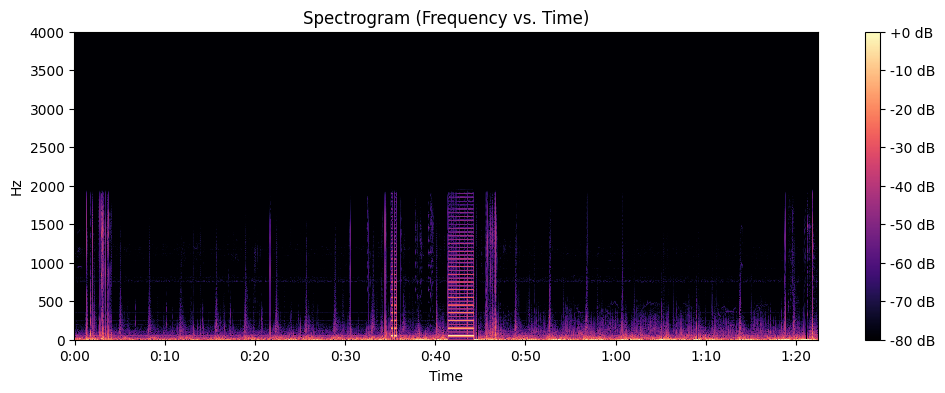

In [92]:
D = lb.amplitude_to_db(np.abs(lb.stft(y)), ref=np.max)

plt.figure(figsize=(12, 4))
lb.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (Frequency vs. Time)")
plt.ylim(0, 4000) # Breathing signals are usually below 4kHz
plt.show()